Import the chosen model

In [1]:
import sys
import os
import pandas as pd

# Add the absolute path to the scripts folder
scripts_path = os.path.abspath("../scripts")
sys.path.append(scripts_path)

from utils import load_model, clean_feature_names




In [2]:

train_final = pd.read_csv(r"C:\Users\DELL\OneDrive\Data Science\Bank_Telemarketing_Prediction_EDSB25_1\data\processed\train_processed.csv")
test_final  = pd.read_csv(r"C:\Users\DELL\OneDrive\Data Science\Bank_Telemarketing_Prediction_EDSB25_1\data/processed/test_processed.csv")

X_train = train_final.drop(columns=["y"])
y_train = train_final["y"]

X_test = test_final.drop(columns=["y"])
y_test = test_final["y"]

In [3]:
models_dir = os.path.abspath("../models")



final_model = load_model("LogisticRegression", models_dir)

✅ Loaded LogisticRegression from c:\Users\DELL\OneDrive\Data Science\Bank_Telemarketing_Prediction_EDSB25_1\models\LogisticRegression.pkl


In [4]:
from data_prep import get_column_types



numerical_cols, categorical_cols = get_column_types(X_train)

In [5]:
from sklearn.preprocessing import OneHotEncoder


ohe = OneHotEncoder(handle_unknown="ignore")
ohe.fit(X_train[categorical_cols])
ohe_feature_names = ohe.get_feature_names_out(categorical_cols)
feature_names = numerical_cols + list(ohe_feature_names)


In [6]:
cleaned_feature_names = clean_feature_names(feature_names)


### SHAP

In [7]:
import shap
import numpy as np

# Use a sample for speed
X_test_sample = X_test[:1000]

# The 'final_model' is the imblearn.pipeline.Pipeline (gs_logreg.best_estimator_)

# Use a small, representative sample of the *preprocessed* training data as background
# This is crucial for shap.Explainer, especially when working with preprocessed data.
X_background_sample = shap.sample(X_train, 500, random_state=42)

# Define a wrapper function that returns only the probability of the positive class
def model_predict_proba_positive(X):
    return final_model.predict_proba(X)[:, 1]

# Initialize the general shap.Explainer with the new wrapper function
# This will ensure exp.base_values is a scalar and exp.values is a 1D array
explainer = shap.Explainer(model_predict_proba_positive, X_background_sample)

# Compute SHAP values for the test sample
# explainer(X_test_sample) returns an Explanation object
shap_values = explainer(X_test_sample)


c:\Users\DELL\OneDrive\Data Science\Bank_Telemarketing_Prediction_EDSB25_1\.bankvenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
PermutationExplainer explainer: 1001it [00:46, 21.28it/s]                         


C:\Users\DELL\AppData\Local\Temp\ipykernel_19100\382765992.py:12: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap_summary = shap.summary_plot(shap_values.values, X_test_sample,feature_names=cleaned_feature_names)


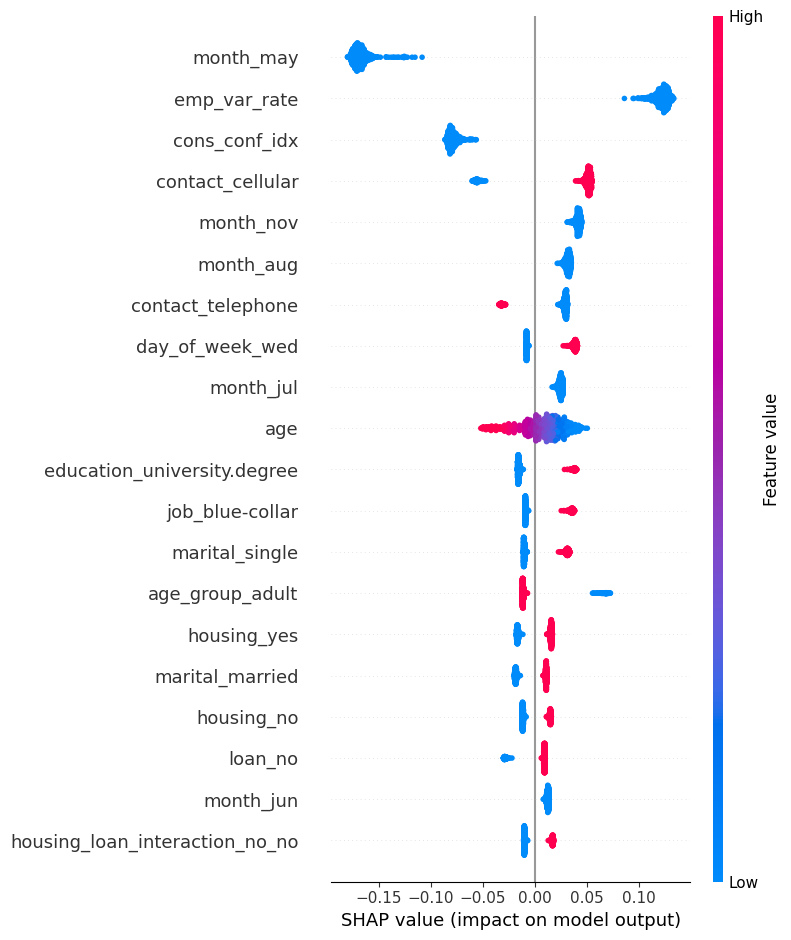

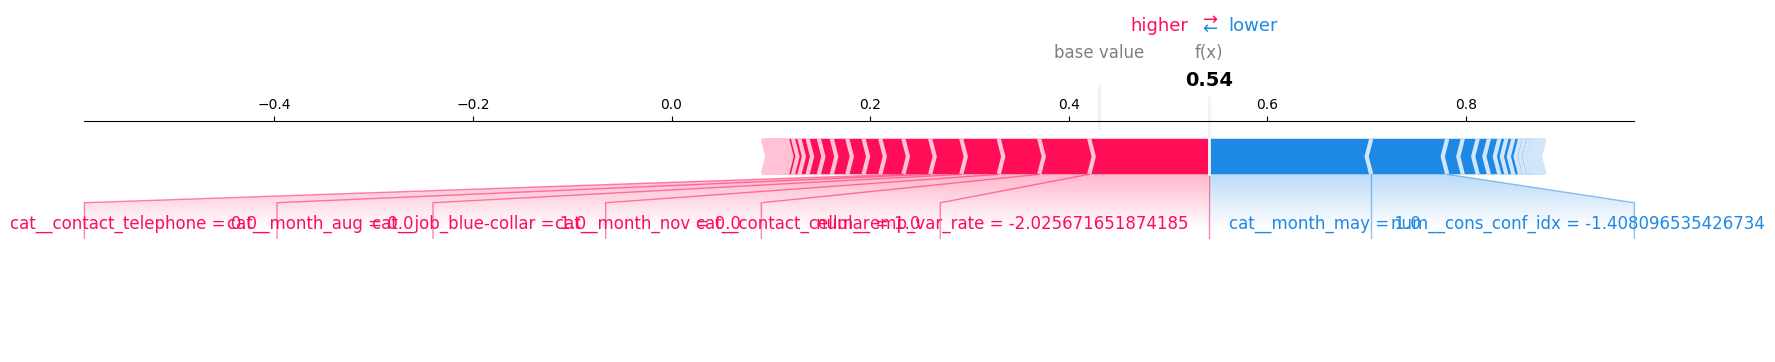

In [11]:

import matplotlib.pyplot as plt

import os

# Define output folder
output_dir = r"C:\Users\DELL\OneDrive\Data Science\Bank_Telemarketing_Prediction_EDSB25_1\reports\figures"

plt.figure(figsize=(20, 12))



shap_summary = shap.summary_plot(shap_values.values, X_test_sample,feature_names=cleaned_feature_names)



# Force plot (single prediction explanation)

shap_fp= shap.force_plot(
    shap_values.base_values[0],
    shap_values.values[0],
    X_test_sample.iloc[0],
    matplotlib=True
)


# Save the current figure
plt.savefig(os.path.join(output_dir, "shap_summary_bar.png"), dpi=200)
plt.close()  # close to avoid overlapping with future plots



C:\Users\DELL\AppData\Local\Temp\ipykernel_19100\2273395738.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


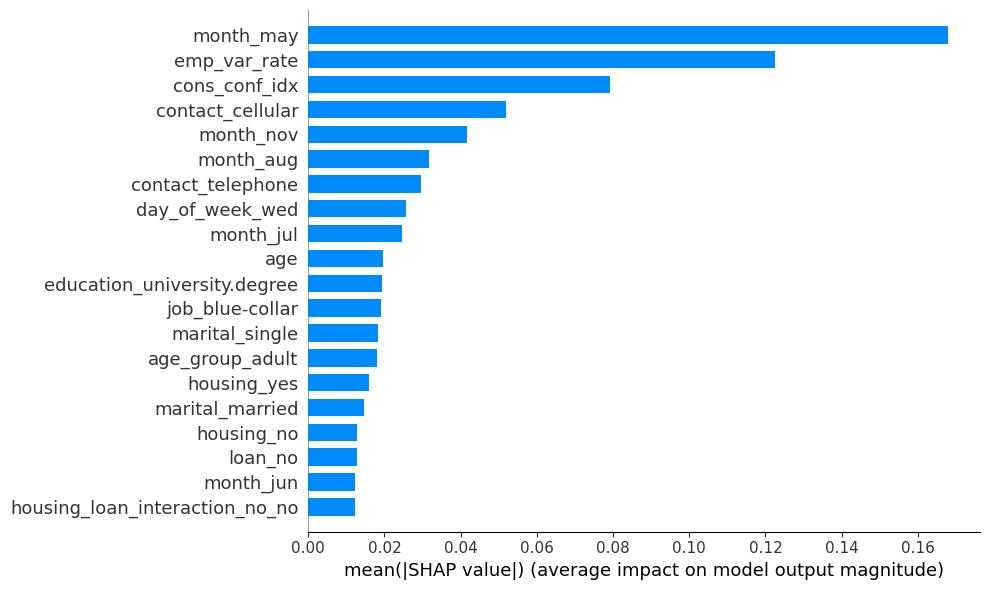

In [9]:
shap.summary_plot(
    shap_values,
    X_test_sample,
    feature_names=cleaned_feature_names,
    plot_type="bar",
    plot_size=(10,6)
)